## Bussiness Problem

* The business problem is to develop a data-driven irrigation prediction system that uses historical environmental and soil conditions—such as soil moisture, temperature, humidity, crop type, and soil temperature—to predict whether irrigation will be required at the next time interval

In [99]:
import pandas as pd
import numpy as np

In [100]:
df = pd.read_excel(r"D:\smart_irrigation_prediction\data\second dataset collected.xlsx")

In [101]:
df.head()

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Tempertuer,irrigation,best time
0,2023-01-06 15:20:00,1,16.0,73.0,46.0,13,1.0,0
1,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0
2,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0
3,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0
4,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,0


In [102]:
df.shape

(3589, 8)

In [103]:
df.columns.tolist()

['Time',
 'crop type',
 'Temperature',
 'Humidity',
 'Soil Moisture',
 'Soil Tempertuer',
 'irrigation ',
 'best time']

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3589 entries, 0 to 3588
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Time             3589 non-null   datetime64[ns]
 1   crop type        3589 non-null   int64         
 2   Temperature      3588 non-null   float64       
 3   Humidity         3586 non-null   float64       
 4   Soil Moisture    3588 non-null   float64       
 5   Soil Tempertuer  3589 non-null   int64         
 6   irrigation       3588 non-null   float64       
 7   best time        3589 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 224.4 KB


In [105]:
df.isna().sum()

Time               0
crop type          0
Temperature        1
Humidity           3
Soil Moisture      1
Soil Tempertuer    0
irrigation         1
best time          0
dtype: int64

In [106]:
(df.isna().sum()/len(df))*100

Time               0.000000
crop type          0.000000
Temperature        0.027863
Humidity           0.083589
Soil Moisture      0.027863
Soil Tempertuer    0.000000
irrigation         0.027863
best time          0.000000
dtype: float64

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
for col in df.columns.tolist():
    print(f"column name is {col}")
    print(df[col].unique())

column name is Time
<DatetimeArray>
['2023-01-06 15:20:00', '2023-01-06 15:17:00', '2023-01-06 15:14:00',
 '2023-01-06 15:11:00', '2023-01-06 15:08:00', '2023-01-06 15:05:00',
 '2023-01-06 15:02:00', '2023-01-06 14:59:00', '2023-01-06 14:56:00',
 '2023-01-06 14:53:00',
 ...
 '2022-12-30 04:23:00', '2022-12-30 04:20:00', '2022-12-30 04:17:00',
 '2022-12-30 04:14:00', '2022-12-30 04:11:00', '2022-12-30 04:08:00',
 '2022-12-30 04:05:00', '2022-12-30 04:02:00', '2022-12-30 03:59:00',
 '2022-12-30 03:56:00']
Length: 3589, dtype: datetime64[ns]
column name is crop type
[1 2]
column name is Temperature
[16. 17. 20. 19. 21. 22. 23. 18. 33. 31. 28. 27. 29. 30. 26. 24. 25. 32.
 nan]
column name is Humidity
[73. 72. 71. 70. nan 69. 75. 76. 78. 80. 74. 68. 77. 79. 81. 84. 85. 87.
 88. 90. 89. 86. 82. 67. 66. 61. 62. 63. 64. 65. 60. 59. 58. 57. 83. 93.
 94. 95.  2. 52. 50. 48. 54. 56. 55.]
column name is Soil Moisture
[46. 47. 45. 48. 49. 50. 53. 61. 60. 62. 63. 64. 65. 67. 41. 42. 43. 44.
 52. 59.

In [109]:
df['Time'].nunique()

3589

In [110]:
df['crop type'].nunique()

2

In [111]:
df['crop type'].value_counts()

crop type
2    2282
1    1307
Name: count, dtype: int64

In [112]:
df['Temperature'].nunique()

18

In [113]:
df['Temperature'].value_counts()

Temperature
20.0    1523
21.0     563
16.0     530
22.0     378
17.0     354
19.0      69
23.0      59
24.0      17
28.0      15
18.0      13
29.0      12
27.0      12
25.0      11
26.0      11
31.0       8
30.0       7
33.0       3
32.0       3
Name: count, dtype: int64

In [114]:
df['Humidity'].nunique()

44

In [115]:
df['Humidity'].value_counts()

Humidity
62.0    1029
61.0     327
63.0     317
72.0     212
58.0     188
68.0     175
67.0     165
71.0     147
69.0     146
64.0     136
73.0     125
66.0      96
70.0      87
59.0      86
65.0      64
60.0      56
74.0      40
57.0      31
93.0      19
75.0      15
79.0      14
56.0      11
78.0      11
80.0      10
54.0      10
76.0       8
89.0       7
87.0       7
85.0       6
77.0       5
81.0       5
82.0       5
83.0       4
84.0       4
88.0       4
52.0       3
86.0       2
90.0       2
55.0       2
94.0       1
50.0       1
2.0        1
95.0       1
48.0       1
Name: count, dtype: int64

In [116]:
df['Soil Moisture'].nunique()

75

In [117]:
df['Soil Tempertuer'].nunique()

14

In [118]:
df['irrigation '].nunique()

2

In [119]:
df['irrigation '].value_counts()

irrigation 
0.0    2997
1.0     591
Name: count, dtype: int64

In [120]:
df['best time'].nunique()

2

In [121]:
df['best time'].value_counts()

best time
0    3224
1     365
Name: count, dtype: int64

In [122]:
df.dtypes

Time               datetime64[ns]
crop type                   int64
Temperature               float64
Humidity                  float64
Soil Moisture             float64
Soil Tempertuer             int64
irrigation                float64
best time                   int64
dtype: object

In [123]:
numerical_columns = [
    'Temperature',
    'Humidity',
    'Soil Moisture',
    'Soil Tempertuer'
]

df[numerical_columns].describe()

,Temperature,Humidity,Soil Moisture,Soil Tempertuer
count,3588.000000,3586.000000,3588.000000,3589.000000
mean,19.708194,65.034858,55.803790,16.996935
std,2.370568,5.757746,9.674344,2.647803
min,16.000000,2.000000,0.000000,12.000000
25%,18.750000,62.000000,53.000000,17.000000
50%,20.000000,63.000000,57.000000,18.000000
75%,21.000000,68.000000,60.000000,18.000000
max,33.000000,95.000000,83.000000,25.000000


In [124]:
for col in numerical_columns:
    print(f"{col}")
    print(df[col].unique())

Temperature
[16. 17. 20. 19. 21. 22. 23. 18. 33. 31. 28. 27. 29. 30. 26. 24. 25. 32.
 nan]
Humidity
[73. 72. 71. 70. nan 69. 75. 76. 78. 80. 74. 68. 77. 79. 81. 84. 85. 87.
 88. 90. 89. 86. 82. 67. 66. 61. 62. 63. 64. 65. 60. 59. 58. 57. 83. 93.
 94. 95.  2. 52. 50. 48. 54. 56. 55.]
Soil Moisture
[46. 47. 45. 48. 49. 50. 53. 61. 60. 62. 63. 64. 65. 67. 41. 42. 43. 44.
 52. 59. 72. 71. 73. 70. 57. 66. 75. 74. 76. 77. 79. 30. 33. 31. 32. 38.
 40. 36. 35. 28. 22. 23. 26. 24. 27. 25. 29. 34. 37. 68. 83. 80. 78. 58.
 54. 51. 39. 55. 56. 69.  5.  6. 82. nan 14. 19. 11. 15. 12. 21. 13. 16.
 17. 20. 10.  0.]
Soil Tempertuer
[13 12 14 15 16 18 19 20 21 22 23 24 17 25]


In [125]:
print("Temperature below 0:")
print(df[df['Temperature'] < 0])

print("\nTemperature above 60:")
print(df[df['Temperature'] > 60])

Temperature below 0:
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Tempertuer, irrigation , best time]
Index: []

Temperature above 60:
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Tempertuer, irrigation , best time]
Index: []


In [126]:
print(f"Humidity value is : ")
print(df[(df['Humidity']<0) | df['Humidity']>100])

Humidity value is : 
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Tempertuer, irrigation , best time]
Index: []


In [127]:
print(f"Soil tempreture : ")
print(df[(df['Soil Tempertuer']<0) | (df['Soil Tempertuer']>60)])

Soil tempreture : 
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Tempertuer, irrigation , best time]
Index: []


In [128]:
for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1
    lower_bound = q1-1.5*iqr
    upper_bound = q3+1.5*iqr

    outlier = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(col)
    print(len(outlier))

Temperature
82
Humidity
108
Soil Moisture
478
Soil Tempertuer
1075


In [129]:
import matplotlib.pyplot as plt 
import seaborn as sns

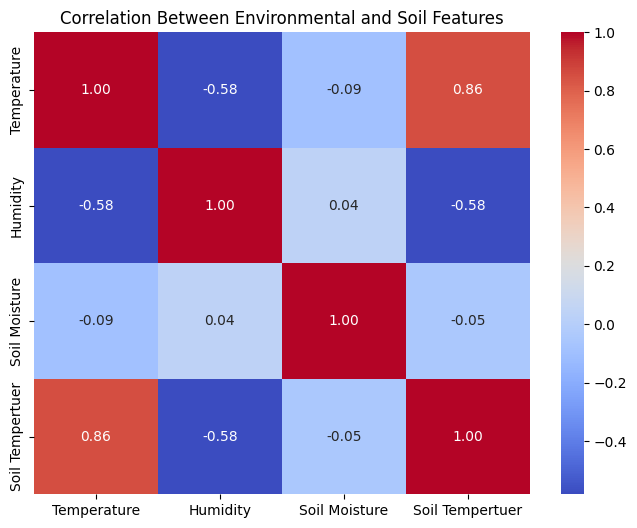

In [130]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Environmental and Soil Features")
plt.show()

In [131]:
df['Time'] = pd.to_datetime(df['Time'])
df.dtypes

Time               datetime64[ns]
crop type                   int64
Temperature               float64
Humidity                  float64
Soil Moisture             float64
Soil Tempertuer             int64
irrigation                float64
best time                   int64
dtype: object

In [132]:
print("Minimum Time is : ",df['Time'].min())
print("Maximum Time is : ",df['Time'].max())

Minimum Time is :  2022-12-30 03:56:00
Maximum Time is :  2023-01-06 15:20:00


In [133]:
df['Time'].sort_values().diff()

3588               NaT
3587   0 days 00:03:00
3586   0 days 00:03:00
3585   0 days 00:03:00
3584   0 days 00:03:00
             ...      
4      0 days 00:03:00
3      0 days 00:03:00
2      0 days 00:03:00
1      0 days 00:03:00
0      0 days 00:03:00
Name: Time, Length: 3589, dtype: timedelta64[ns]

In [134]:
df = df.sort_values('Time').reset_index(drop=True)

In [135]:
df

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Tempertuer,irrigation,best time
0,2022-12-30 03:56:00,1,NaN,56.0,0.0,19,1.0,1
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,1
...,...,...,...,...,...,...,...,...
3584,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,0
3585,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0
3586,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0
3587,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0


In [136]:
df_clean = df.copy()

In [137]:
df_clean.rename(columns={
    "Soil Tempertuer": "Soil Temperature",
    "irrigation ": "irrigation"
},inplace=True)

In [138]:
df_clean

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,best time
0,2022-12-30 03:56:00,1,NaN,56.0,0.0,19,1.0,1
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,1
...,...,...,...,...,...,...,...,...
3584,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,0
3585,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0
3586,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0
3587,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0


In [139]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3589 entries, 0 to 3588
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Time              3589 non-null   datetime64[ns]
 1   crop type         3589 non-null   int64         
 2   Temperature       3588 non-null   float64       
 3   Humidity          3586 non-null   float64       
 4   Soil Moisture     3588 non-null   float64       
 5   Soil Temperature  3589 non-null   int64         
 6   irrigation        3588 non-null   float64       
 7   best time         3589 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 224.4 KB


In [140]:
df_clean = df_clean.sort_values('Time').reset_index(drop=True)

In [141]:
df_clean

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,best time
0,2022-12-30 03:56:00,1,NaN,56.0,0.0,19,1.0,1
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,1
...,...,...,...,...,...,...,...,...
3584,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,0
3585,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0
3586,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0
3587,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0


In [142]:
sensor_columns = ['Temperature', 'Humidity', 'Soil Moisture']

df_clean[sensor_columns] = df_clean[sensor_columns].interpolate(
    method='linear',
    limit_direction='both'
)

df_clean[sensor_columns].isna().sum()

Temperature      0
Humidity         0
Soil Moisture    0
dtype: int64

In [143]:
df_clean

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,best time
0,2022-12-30 03:56:00,1,23.0,56.0,0.0,19,1.0,1
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,1
...,...,...,...,...,...,...,...,...
3584,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,0
3585,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0
3586,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0
3587,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0


In [144]:
df_clean = df_clean.dropna(subset=['irrigation']).reset_index(drop=True)

In [145]:
df_clean.shape

(3588, 8)

In [146]:
df_clean.isnull().sum()

Time                0
crop type           0
Temperature         0
Humidity            0
Soil Moisture       0
Soil Temperature    0
irrigation          0
best time           0
dtype: int64

In [147]:
print("Temperature range:")
print(df_clean["Temperature"].min(), "to", df_clean["Temperature"].max())

print("\nHumidity range:")
print(df_clean["Humidity"].min(), "to", df_clean["Humidity"].max())

print("\nSoil Moisture range:")
print(df_clean["Soil Moisture"].min(), "to", df_clean["Soil Moisture"].max())

print("\nSoil Temperature range:")
print(df_clean["Soil Temperature"].min(), "to", df_clean["Soil Temperature"].max())

print("\nCrop Type values:")
print(df_clean["crop type"].unique())

print("\nIrrigation values:")
print(df_clean["irrigation"].unique())

Temperature range:
16.0 to 33.0

Humidity range:
2.0 to 95.0

Soil Moisture range:
0.0 to 83.0

Soil Temperature range:
12 to 25

Crop Type values:
[1 2]

Irrigation values:
[1. 0.]


In [148]:
df_clean.dtypes

Time                datetime64[ns]
crop type                    int64
Temperature                float64
Humidity                   float64
Soil Moisture              float64
Soil Temperature             int64
irrigation                 float64
best time                    int64
dtype: object

In [149]:
print("Invalid crop type values:")
print(df_clean[~df_clean["crop type"].isin([1, 2])])

print("\nInvalid irrigation values:")
print(df_clean[~df_clean["irrigation"].isin([0, 1])])

Invalid crop type values:
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Temperature, irrigation, best time]
Index: []

Invalid irrigation values:
Empty DataFrame
Columns: [Time, crop type, Temperature, Humidity, Soil Moisture, Soil Temperature, irrigation, best time]
Index: []


In [150]:
model_df = df_clean[
    ["Time",
     "crop type",
     "Temperature",
     "Humidity",
     "Soil Moisture",
     "Soil Temperature",
     "irrigation"]
].copy()

model_df.head()

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation
0,2022-12-30 03:56:00,1,23.0,56.0,0.0,19,1.0
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0


In [151]:
model_df.isna().sum()

Time                0
crop type           0
Temperature         0
Humidity            0
Soil Moisture       0
Soil Temperature    0
irrigation          0
dtype: int64

In [152]:
model_df['Soil Moisture change'] = model_df['Soil Moisture'].diff()

In [153]:
model_df

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,Soil Moisture change
0,2022-12-30 03:56:00,1,23.0,56.0,0.0,19,1.0,NaN
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,10.0
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,11.0
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,11.0
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,11.0
...,...,...,...,...,...,...,...,...
3583,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,-1.0
3584,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0.0
3585,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0.0
3586,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0.0


In [154]:
model_df["Soil Moisture Rolling Mean"] = (
    model_df["Soil Moisture"]
    .rolling(window=5)
    .mean()
)

In [155]:
model_df

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,Soil Moisture change,Soil Moisture Rolling Mean
0,2022-12-30 03:56:00,1,23.0,56.0,0.0,19,1.0,NaN,NaN
1,2022-12-30 03:59:00,1,23.0,58.0,10.0,24,0.0,10.0,NaN
2,2022-12-30 04:02:00,1,23.0,61.0,21.0,23,0.0,11.0,NaN
3,2022-12-30 04:05:00,1,24.0,59.0,32.0,22,0.0,11.0,NaN
4,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,11.0,21.2
...,...,...,...,...,...,...,...,...,...
3583,2023-01-06 15:08:00,1,16.0,73.0,46.0,13,1.0,-1.0,46.2
3584,2023-01-06 15:11:00,1,16.0,73.0,46.0,13,1.0,0.0,46.4
3585,2023-01-06 15:14:00,1,16.0,73.0,46.0,13,1.0,0.0,46.4
3586,2023-01-06 15:17:00,1,16.0,73.0,46.0,13,1.0,0.0,46.2


In [156]:
model_df = model_df.dropna().reset_index(drop=True)

In [157]:
model_df.head()

,Time,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,irrigation,Soil Moisture change,Soil Moisture Rolling Mean
0,2022-12-30 04:08:00,1,23.0,58.0,43.0,20,1.0,11.0,21.2
1,2022-12-30 04:11:00,1,23.0,58.0,10.0,24,0.0,-33.0,23.2
2,2022-12-30 04:14:00,1,24.0,59.0,16.0,23,0.0,6.0,24.4
3,2022-12-30 04:17:00,1,24.0,61.0,25.0,23,0.0,9.0,25.2
4,2022-12-30 04:20:00,1,25.0,60.0,33.0,22,0.0,8.0,25.4


In [158]:
x = model_df[
    ["crop type",
     "Temperature",
     "Humidity",
     "Soil Moisture",
     "Soil Temperature",
     "Soil Moisture change",
     "Soil Moisture Rolling Mean"]
]

y = model_df["irrigation"]

In [159]:
x.shape

(3584, 7)

In [160]:
y.shape

(3584,)

In [161]:
train_size = int(len(x)*0.70)
val_size = int(len(x)*0.15)

In [162]:
x_train = x.iloc[:train_size,:]
y_train = y.iloc[:train_size]

x_val = x.iloc[train_size:train_size+val_size,:]
y_val = y.iloc[train_size:train_size+val_size]

x_test = x.iloc[train_size+val_size:,:]
y_test = y.iloc[train_size+val_size:]

In [163]:
x_train

,crop type,Temperature,Humidity,Soil Moisture,Soil Temperature,Soil Moisture change,Soil Moisture Rolling Mean
0,1,23.0,58.0,43.0,20,11.0,21.2
1,1,23.0,58.0,10.0,24,-33.0,23.2
2,1,24.0,59.0,16.0,23,6.0,24.4
3,1,24.0,61.0,25.0,23,9.0,25.2
4,1,25.0,60.0,33.0,22,8.0,25.4
...,...,...,...,...,...,...,...
2503,2,20.0,63.0,58.0,18,5.0,55.6
2504,2,20.0,63.0,59.0,18,1.0,56.4
2505,2,20.0,63.0,58.0,18,-1.0,56.8
2506,2,20.0,63.0,56.0,18,-2.0,56.8


In [164]:
y_train

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2503    0.0
2504    0.0
2505    0.0
2506    0.0
2507    0.0
Name: irrigation, Length: 2508, dtype: float64

In [165]:
from sklearn.preprocessing import MinMaxScaler

In [166]:
scaler = MinMaxScaler()

In [167]:
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [168]:
len(x_train_scaled)

2508

In [169]:
def create_sequence(X, y, time_steps=20):
    X_seq = []
    y_seq = []

    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)


# Records 0–19 → predict record 20
# Records 1–20 → predict record 21
# Records 2–21 → predict record 22

In [170]:
time_steps = 20

x_train_seq, y_train_seq = create_sequence(
    x_train_scaled,
    y_train,
    time_steps
)

x_val_seq, y_val_seq = create_sequence(
    x_val_scaled,
    y_val,
    time_steps
)

x_test_seq, y_test_seq = create_sequence(
    x_test_scaled,
    y_test,
    time_steps
)

In [171]:
x_train_seq,y_train_seq

(array([[[0.        , 0.375     , 0.60215054, ..., 0.375     ,
          0.65546218, 0.        ],
         [0.        , 0.375     , 0.60215054, ..., 0.875     ,
          0.28571429, 0.03460208],
         [0.        , 0.4375    , 0.61290323, ..., 0.75      ,
          0.61344538, 0.05536332],
         ...,
         [0.        , 0.6875    , 0.61290323, ..., 0.5       ,
          0.65546218, 0.25259516],
         [0.        , 0.75      , 0.64516129, ..., 0.375     ,
          0.64705882, 0.19377163],
         [0.        , 0.6875    , 0.67741935, ..., 0.25      ,
          0.70588235, 0.39100346]],
 
        [[0.        , 0.375     , 0.60215054, ..., 0.875     ,
          0.28571429, 0.03460208],
         [0.        , 0.4375    , 0.61290323, ..., 0.75      ,
          0.61344538, 0.05536332],
         [0.        , 0.4375    , 0.6344086 , ..., 0.75      ,
          0.63865546, 0.06920415],
         ...,
         [0.        , 0.75      , 0.64516129, ..., 0.375     ,
          0.64705882, 0.

In [172]:
x_train_seq.shape

(2488, 20, 7)

In [173]:
y_train_seq.shape

(2488,)

In [174]:
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense

In [175]:
base_model = Sequential()

base_model.add(LSTM(32,input_shape=(x_train_seq.shape[1],x_train_seq.shape[2])))
base_model.add(Dense(1,activation='sigmoid'))

c:\Users\ASUS\.conda\envs\smart_irrigation\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [176]:
base_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)  

In [177]:
history = base_model.fit(
    x_train_seq,
    y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=20,
    batch_size=32
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9526 - loss: 0.2313 - val_accuracy: 0.5861 - val_loss: 1.2802
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9526 - loss: 0.1779 - val_accuracy: 0.5861 - val_loss: 1.5442
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9526 - loss: 0.1702 - val_accuracy: 0.5861 - val_loss: 1.4118
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9526 - loss: 0.1697 - val_accuracy: 0.5861 - val_loss: 1.5729
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9526 - loss: 0.1695 - val_accuracy: 0.5861 - val_loss: 1.3661
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9526 - loss: 0.1665 - val_accuracy: 0.5861 - val_loss: 1.5215
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9526 - loss: 0.1634 - val_accuracy: 0.5861 - val_loss: 1.3538
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9526 - loss: 0.1636 - val_accuracy: 0.5861 - val_loss:

In [178]:
print("Training Accuracy:",
      history.history["accuracy"][-1])

print("Validation Accuracy:",
      history.history["val_accuracy"][-1])

Training Accuracy: 0.9573954939842224
Validation Accuracy: 0.5860735177993774


In [179]:
test_loss, test_accuracy = base_model.evaluate(
    x_test_seq,
    y_test_seq
)

print("Test Accuracy:", test_accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6975 - loss: 0.5106 
Test Accuracy: 0.69749516248703


In [180]:
import keras_tuner as kt

In [181]:
class  IrrigationHyperModel(kt.HyperModel):
    def build(self,hp):
        model = Sequential()

        lstm_units = hp.Choice(
            "lstm_units",
            values=[16,32,64]
        )
        model.add(
            LSTM(
                units=lstm_units,
                input_shape=(x_train_seq.shape[1],x_train_seq.shape[2])
            )
        )
        use_dropout = hp.Boolean(
            "use_dropout",
            default=False
        )

        if use_dropout:
            dropout_rate = hp.Choice(
                "dropout_rate",
                values=[0.1, 0.2, 0.3, 0.4]
            )

            model.add(Dropout(dropout_rate))

        model.add(Dense(1,activation='sigmoid'))

        learning_rate = hp.Choice(
            "learning_rate",
            values=[0.001, 0.0005]
        )

        optimizer_name = hp.Choice(
            "optimizer",
            values=["adam", "rmsprop"]
        )

        if optimizer_name == 'adam':
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )
        else:
            optimizer = tf.keras.optimizers.RMSprop(
                learning_rate=learning_rate
            )

        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    def fit(self,hp,model,*args,**kwargs):
        batch_size = hp.Choice(
            "batch_size",
            values=[16,32,64]
        )

        return model.fit(*args,batch_size=batch_size,**kwargs)


In [182]:
hypermodel = IrrigationHyperModel()

In [183]:
tuner = kt.RandomSearch(
    hypermodel,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory = 'tuner_results',
    project_name='smart_irrigation_lstm'
)

Reloading Tuner from tuner_results\smart_irrigation_lstm\tuner0.json


In [184]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [185]:
tuner.search(
    x_train_seq,
    y_train_seq,
    validation_data=(x_val_seq,y_val_seq),
    epochs=30,
    callbacks=[early_stopping]
)

In [186]:
best_hyperparameters = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [187]:
print("Best Hyperparameters:")

print(
    "LSTM Units:",
    best_hyperparameters.get("lstm_units")
)

print(
    "Use Dropout:",
    best_hyperparameters.get("use_dropout")
)

if best_hyperparameters.get("use_dropout"):
    print(
        "Dropout Rate:",
        best_hyperparameters.get("dropout_rate")
    )

print(
    "Optimizer:",
    best_hyperparameters.get("optimizer")
)

print(
    "Learning Rate:",
    best_hyperparameters.get("learning_rate")
)

print(
    "Batch Size:",
    best_hyperparameters.get("batch_size")
)

Best Hyperparameters:
LSTM Units: 16
Use Dropout: False
Optimizer: adam
Learning Rate: 0.001
Batch Size: 32


In [188]:
tuner.results_summary()

Results summary
Results in tuner_results\smart_irrigation_lstm
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
lstm_units: 16
use_dropout: False
learning_rate: 0.001
optimizer: adam
batch_size: 32
Score: 0.5860735177993774

Trial 02 summary
Hyperparameters:
lstm_units: 64
use_dropout: True
learning_rate: 0.001
optimizer: rmsprop
batch_size: 16
dropout_rate: 0.1
Score: 0.5860735177993774

Trial 05 summary
Hyperparameters:
lstm_units: 16
use_dropout: False
learning_rate: 0.0005
optimizer: adam
batch_size: 16
dropout_rate: 0.2
Score: 0.5860735177993774

Trial 04 summary
Hyperparameters:
lstm_units: 16
use_dropout: False
learning_rate: 0.0005
optimizer: adam
batch_size: 64
dropout_rate: 0.4
Score: 0.5860735177993774

Trial 06 summary
Hyperparameters:
lstm_units: 16
use_dropout: True
learning_rate: 0.001
optimizer: adam
batch_size: 64
dropout_rate: 0.1
Score: 0.5860735177993774

Trial 03 summary
Hyperparameters:
lstm_units: 16
use_dr

In [189]:
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\ASUS\.conda\envs\smart_irrigation\lib\site-packages\keras\src\saving\saving_lib.py:868: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [190]:
best_model

<Sequential name=sequential, built=True>

In [191]:
test_loss, test_accuracy = best_model.evaluate(
    x_test_seq,
    y_test_seq
)

print("Tuned Model Test Loss:", test_loss)
print("Tuned Model Test Accuracy:", test_accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5491 - loss: 1.1443  
Tuned Model Test Loss: 1.1443132162094116
Tuned Model Test Accuracy: 0.5491329431533813


In [192]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.unique(y_train_seq.astype(int))
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train_seq.astype(int)
)
class_weight = {int(label): float(weight) for label, weight in zip(class_labels, class_weights)}

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    x_train_seq,
    y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=30,
    batch_size=best_hyperparameters.get('batch_size'),
    class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9526 - loss: 0.8651 - val_accuracy: 0.7795 - val_loss: 0.6036
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8264 - loss: 0.6304 - val_accuracy: 0.7679 - val_loss: 0.5849
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6298 - loss: 0.6029 - val_accuracy: 0.7776 - val_loss: 0.5753
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6901 - loss: 0.5747 - val_accuracy: 0.7950 - val_loss: 0.5172
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7729 - loss: 0.5616 - val_accuracy: 0.6654 - val_loss: 0.5732
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7926 - loss: 0.5387 - val_accuracy: 0.6750 - val_loss: 0.6284
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7765 - loss: 0.5235 - val_accuracy: 0.6712 - val_loss: 0.6445
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7898 - loss: 0.5144 - val_accuracy: 0.6673 - val_loss:

In [193]:
from sklearn.metrics import f1_score

In [194]:
val_prob = best_model.predict(x_val_seq).ravel()
thresholds = np.linspace(0.2, 0.8, 61)
best_threshold = None
best_f1 = -1

for threshold in thresholds:
    pred = (val_prob >= threshold).astype(int)
    f1 = f1_score(y_val_seq, pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

y_pred_prob = best_model.predict(x_test_seq).ravel()
y_pred = (y_pred_prob >= best_threshold).astype(int)
print(f'Chosen threshold: {best_threshold:.2f} (F1={best_f1:.4f})')

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Chosen threshold: 0.44 (F1=0.7576)


In [195]:
from sklearn.metrics import classification_report, f1_score

print(
    classification_report(
        y_test_seq.astype(int),
        y_pred.astype(int),
        target_names=["No Irrigation", "Irrigation"],
        zero_division=0
    )
)

               precision    recall  f1-score   support

No Irrigation       0.88      0.86      0.87       285
   Irrigation       0.84      0.85      0.85       234

     accuracy                           0.86       519
    macro avg       0.86      0.86      0.86       519
 weighted avg       0.86      0.86      0.86       519



In [197]:
best_model.save("../models/irrigation_lstm.keras")

In [198]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [199]:
joblib.dump(best_threshold, "../models/threshold.pkl")

['../models/threshold.pkl']